In [28]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [29]:
%run utils_regions.ipynb

In [163]:
def accum_plot(file, aerosol, time_range=None):
    ds = xr.open_dataset(file)
    seasons = xr.groupers.SeasonResampler(['DJF', 'MAM', 'JJA', 'SON'])
    colors = list(mcolors.TABLEAU_COLORS.keys())

    if time_range != None:
        start = str(time_range[0])
        end = str(time_range[1])
        ds = ds.sel(time=slice(start, end))
    else:
        start = str((ds['date'].values)[0])[:4]
        end = str((ds['date'].values)[len(ds['date'])-1])[:4]
    
    ds_seasonal = ds.resample({'time':seasons}).mean()
    plotting = []
    for region in reg_list:
        region = region.rename({'latitude':'lat', 'longitude':'lon'})
        adj_region = region.interp({'lat':ds_seasonal.lat, 'lon':ds_seasonal.lon}, method = 'nearest')
        regional_ds = ds_seasonal.where(adj_region > 0).fillna(0).drop_vars('region')
        avg_ds = regional_ds.mean(dim=['lat','lon'])
        plotting.append(avg_ds)

    zorders = list(p.mean(dim=['time','date']) for p in plotting).sort()
    print(p.mean(dim=['time','date']) for p in plotting)
    fig = plt.figure(figsize=(14,12))
    ax = plt.axes()
    for i in range(len(plotting)):
        plt.plot(plotting[i].time, plotting[i].bb, label=str(reg_list[i].region.values), color=colors[i])
        plt.fill_between(plotting[i].time, plotting[i].bb)
    plt.legend()
    plt.xlabel('Time')
    plt.ylabel('molecules/cm²/s')
    plt.title(f' {aerosol} Concentration by HTAP3 Region, {start} - {end}')
    
    return None

<generator object accum_plot.<locals>.<genexpr> at 0x1539a5772960>


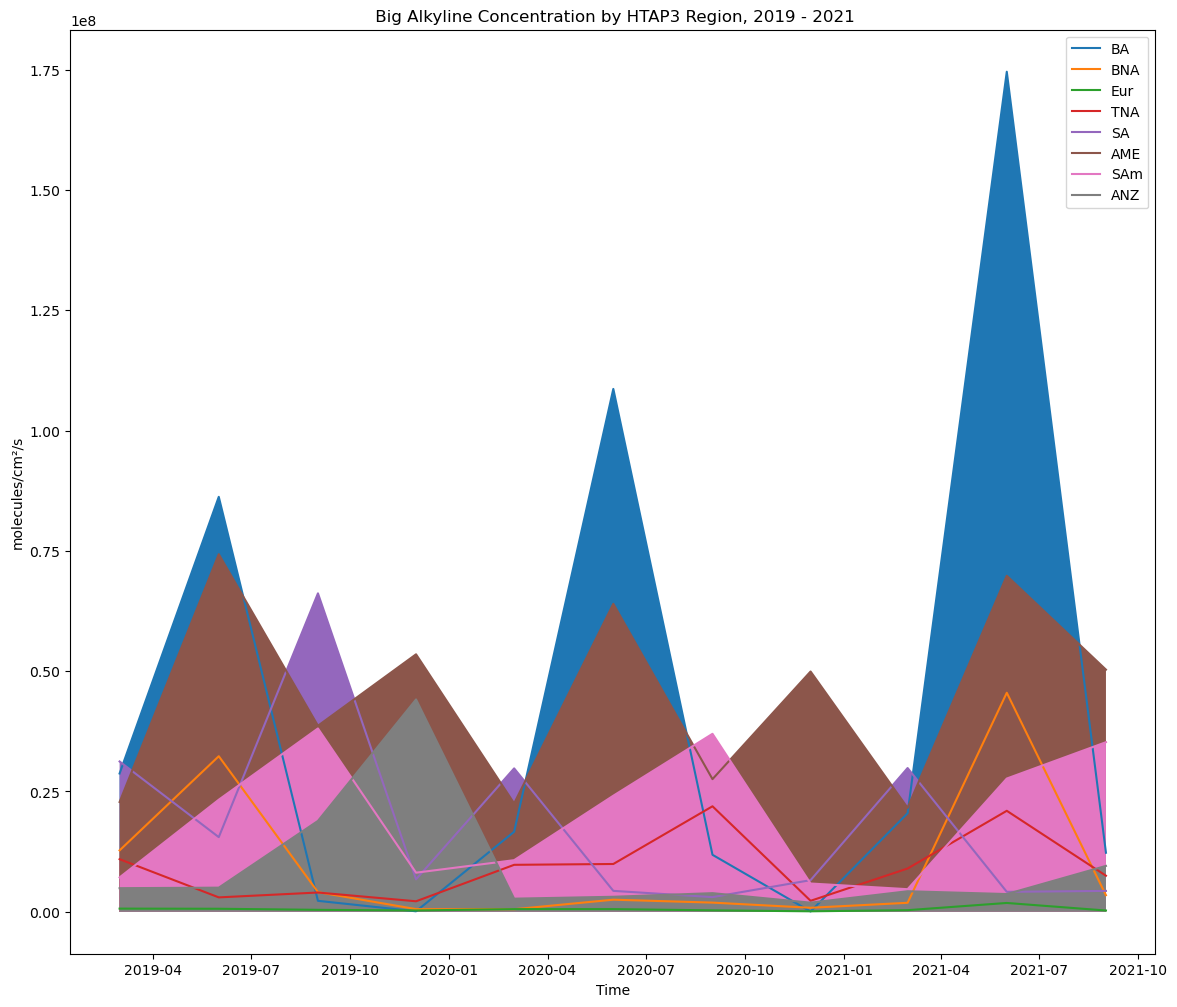

In [164]:
accum_plot('/glade/work/ekeefe/research_code/gfas4htap_fire_emissions/gfas4htap-moz_BIGALK_bb_2003-2023_f09_c20260306.nc', 'Big Alkyline', time_range=[2019,2021])